# **NASA 이미지 처리 실습**

In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt; import random
import tensorflow as tf; from tensorflow import keras
import cv2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 33.9 MB/s eta 0:00:00


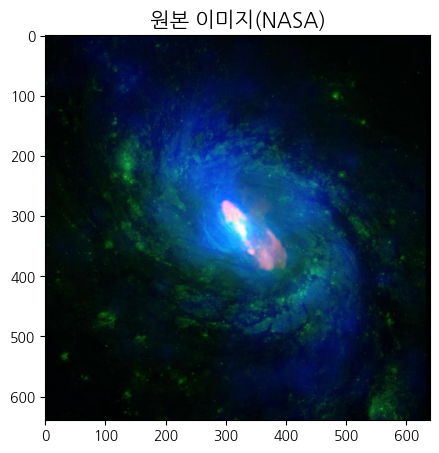

In [ ]:
image=cv2.imread('blackhole.jpg')
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("원본 이미지(NASA)", fontsize=15)
plt.show()

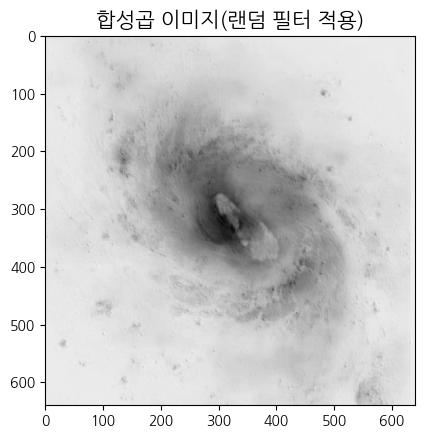

In [ ]:
# 컬러 이미지 합성곱 함수 정의
def convRGB(input, filter):   # 컬러 이미지 합성곱 함수
  map=np.zeros(shape=(input.shape[0]-2, input.shape[1]-2)) # 특성맵 초기화

  for i in range(map.shape[0]):   # 행과
    for j in range(map.shape[1]): # 열을 이동하며 반복

        # 채널별 패치 구성
        patch_R=input[i:i+3, j:j+3, 0]
        patch_G=input[i:i+3, j:j+3, 1]
        patch_B=input[i:i+3, j:j+3, 2]

        map[i, j]=np.sum(patch_R * filter[:,:,0] # 색상 채널별 내적의 합
                           + patch_G * filter[:,:,1]
                           + patch_B * filter[:,:,2] )
  return map

# 패딩
pad_image = np.pad(image, pad_width=[(1, 1), (1, 1), (0, 0)], mode='constant')  # 높이와 너비 축만 상하 좌우로 0을 채우고 채널 축은 그대로 둡니다.

# 랜덤 필터 지정 (채널마다 3x3)
filt=np.random.normal(size=(3, 3, 3))

# 사용자 정의 함수 호출하여 특성맵 계산
f_map=convRGB(pad_image, filt)

# 특성맵 시각화
plt.imshow(f_map, cmap='gray')
plt.title("합성곱 이미지(랜덤 필터 적용)", fontsize=15)
plt.show()